Task 1: Create a Line Plot Showing Cost Trends Over Time 
Create a chart that shows how total_cost changes over order_month. 
Write code to: 
•	Group by order_month and calculate sum of total_cost for each month 
•	Create a line plot with order_month on x-axis and total cost on y-axis 
•	Add a title: "Total Order Cost by Month" 
•	Add x-axis label: "Month" 
•	Add y-axis label: "Total Cost ($)" 
•	Add a legend 
•	Save the figure as "cost_trend.png" 

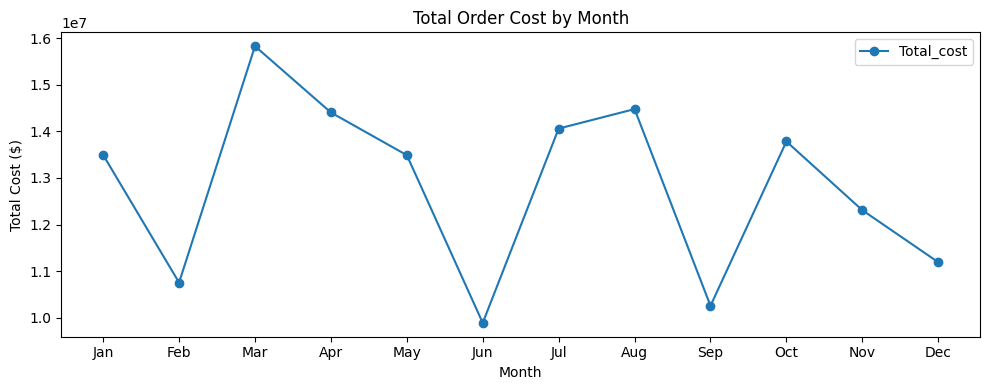

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the sampe data
df = pd.read_csv("supply_chain_cleaned_dataset.csv")

# Groupby by order month and calc total cost sum for each month
# Retrieve month from order date
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.month # To get the month number
monthly_cost = df.groupby('order_month')['total_cost'].sum().reset_index()

# Mapping of month names to their numbers
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_cost['order_month'] = monthly_cost['order_month'].map(month_names)

# Create a lineplot with order_month on x-axis and total cost on y-axis
plt.figure(figsize=(10, 4)) # Setting figure size
plt.plot(monthly_cost['order_month'], monthly_cost['total_cost'], marker= 'o', label='Total_cost')

# To add a title, xlabel, ylabel
plt.title('Total Order Cost by Month') 
plt.xlabel('Month')
plt.ylabel('Total Cost ($)')
# plt.xticks(rotation=45) # As a result of the overlapping of the xlabels, there was need to change the rotation of the labels.
plt.legend()
plt.tight_layout()
plt.savefig('cost_trend.png')
plt.show()

Answer this: Does cost increase or decrease over time? Are there patterns? 
There is no consistent increase or decrease over time just giving cyclical patterns showing peaks in March and August

Task 2: Create Bar Charts Comparing Suppliers 
Create a chart showing key metrics for each supplier. 
Create Chart 1: Average Cost by Supplier 
•	Group by supplier_name, calculate mean total_cost 
•	Create a bar chart with supplier_name on x-axis, avg cost on y-axis 
•	Add title and labels 
•	Add a color for each bar (use different colors) 
Create Chart 2: Order Count by Supplier 
•	Group by supplier_name, calculate count of orders 
•	Create a bar chart with supplier_name on x-axis, order count on y-axis 
•	Add title and labels 
Save both charts. 
Answer this: Which supplier is most expensive? Which has most orders? 

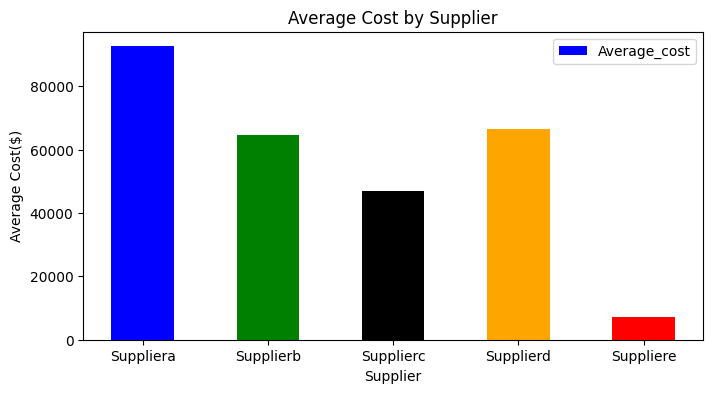

In [4]:
# Group by supplier_name, calculate mean total_cost
chart1 = df.groupby('supplier_name')['total_cost'].mean().reset_index()

# Create a bar chart
plt.figure(figsize=(8, 4))
plt.bar(chart1['supplier_name'], chart1['total_cost'], label='Average_cost', color=['blue', 'green', 'black', 'orange', 'red'], width=0.5)
plt.title('Average Cost by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Average Cost($)')
plt.legend()
plt.savefig('Average_cost_bar.png')
plt.show()

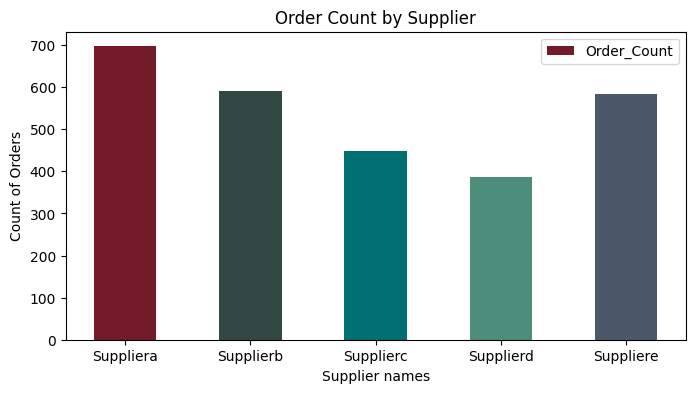

In [5]:
# Group by supplier_name, calculate count of orders
chart2 = df.groupby('supplier_name')['order_id'].count().reset_index()
chart2.columns = ['supplier_name', 'order_count']

# Create a bar chart with supplier_name on x-axis, order count on y-axis
plt.figure(figsize=(8, 4))
plt.bar(chart2['supplier_name'], chart2['order_count'], label='Order_Count', color=['#731b2b', '#324842', '#007075', '#4b8e79', '#4c5869'], width=0.5)
plt.title('Order Count by Supplier')
plt.xlabel('Supplier names')
plt.ylabel('Count of Orders')
plt.legend()
plt.savefig('Order_count_bar.png')
plt.show()

Task 3: Create a Scatter Plot Showing Relationship Between Two Variables 
Create a chart showing the relationship between quantity and total_cost. 
Write code to: 
•	Create a scatter plot with quantity on x-axis and total_cost on y-axis 
•	Each point represents one order 
•	Add title: "Order Quantity vs Cost" 
•	Add x-axis label: "Quantity (units)" 
•	Add y-axis label: "Cost ($)" 
•	Add a legend 
•	Save as "quantity_vs_cost.png"  

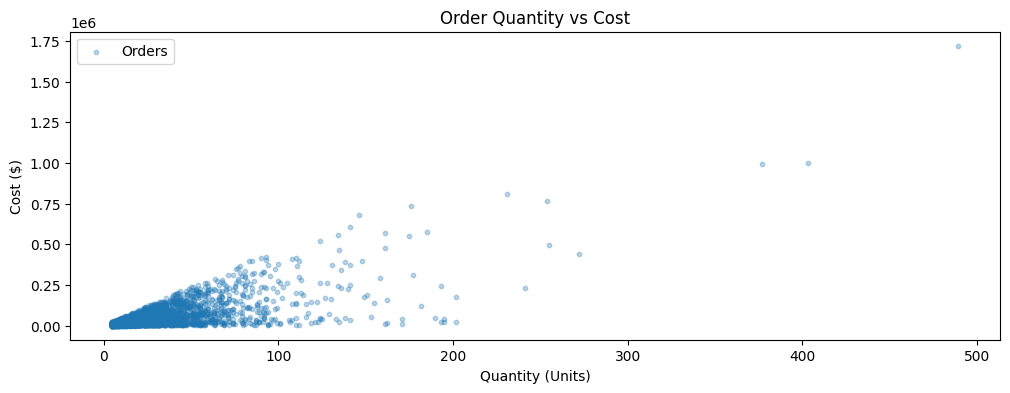

In [6]:
plt.figure(figsize=(12,4))
plt.scatter(df['quantity'], df['total_cost'], label='Orders', alpha=0.3, s=10)
plt.title('Order Quantity vs Cost')
plt.xlabel('Quantity (Units)')
plt.ylabel('Cost ($)')
plt.legend()
plt.savefig('quantity_vs_cost.png')
plt.show()

Answer this: Do larger orders cost more? Is the relationship linear or scattered?
Yes, Larger orders cost more showing a positive relationship between quantity and cost. However,it is scattered rather than linear as most orders are clustered at low quantittes.

Task 4: Create a Histogram Showing Distribution of a Variable 
Create a chart showing how order costs are distributed. 
Write code to: 
•	Create a histogram of total_cost column 
•	Use 20 bins (20 bars showing the distribution) 
•	Add title: "Distribution of Order Costs" 
•	Add x-axis label: "Cost ($)" 
•	Add y-axis label: "Frequency (Number of Orders)" 
•	Save as "cost_distribution.png" 

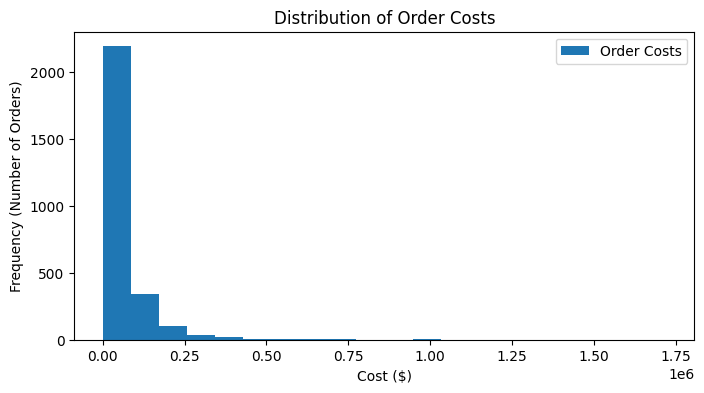

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(df['total_cost'], bins=20, label='Order Costs')
plt.title('Distribution of Order Costs')
plt.xlabel('Cost ($)')
plt.ylabel('Frequency (Number of Orders)')
plt.legend()
plt.savefig('cost_distribution.png')
plt.show()

Answer this: Are most orders cheap or expensive? Is the distribution normal or skewed? 
Most orders are cheap as they are rightly skewed meaning most values are low while few are very high.

Task 5: Create Multiple Plots on One Figure 
Create a figure with multiple subplots showing different aspects of the data. 
Write code to: 
•	Create a figure with 2 rows and 2 columns (4 subplots total) 
•	Subplot 1 (top left): Line plot of total cost by month 
•	Subplot 2 (top right): Bar chart of order count by supplier 
•	Subplot 3 (bottom left): Histogram of delivery days 
•	Subplot 4 (bottom right): Scatter plot of quantity vs cost 
•	Add a title to the entire figure: "Supply Chain Analysis Dashboard" 
•	Make sure each subplot has its own title and labels 
•	Adjust spacing so plots don't overlap 
•	Save as "dashboard.png" 
This creates a professional dashboard showing multiple insights at once. 

C:\Users\u-techz hub\AppData\Local\Temp\ipykernel_19216\2724637850.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


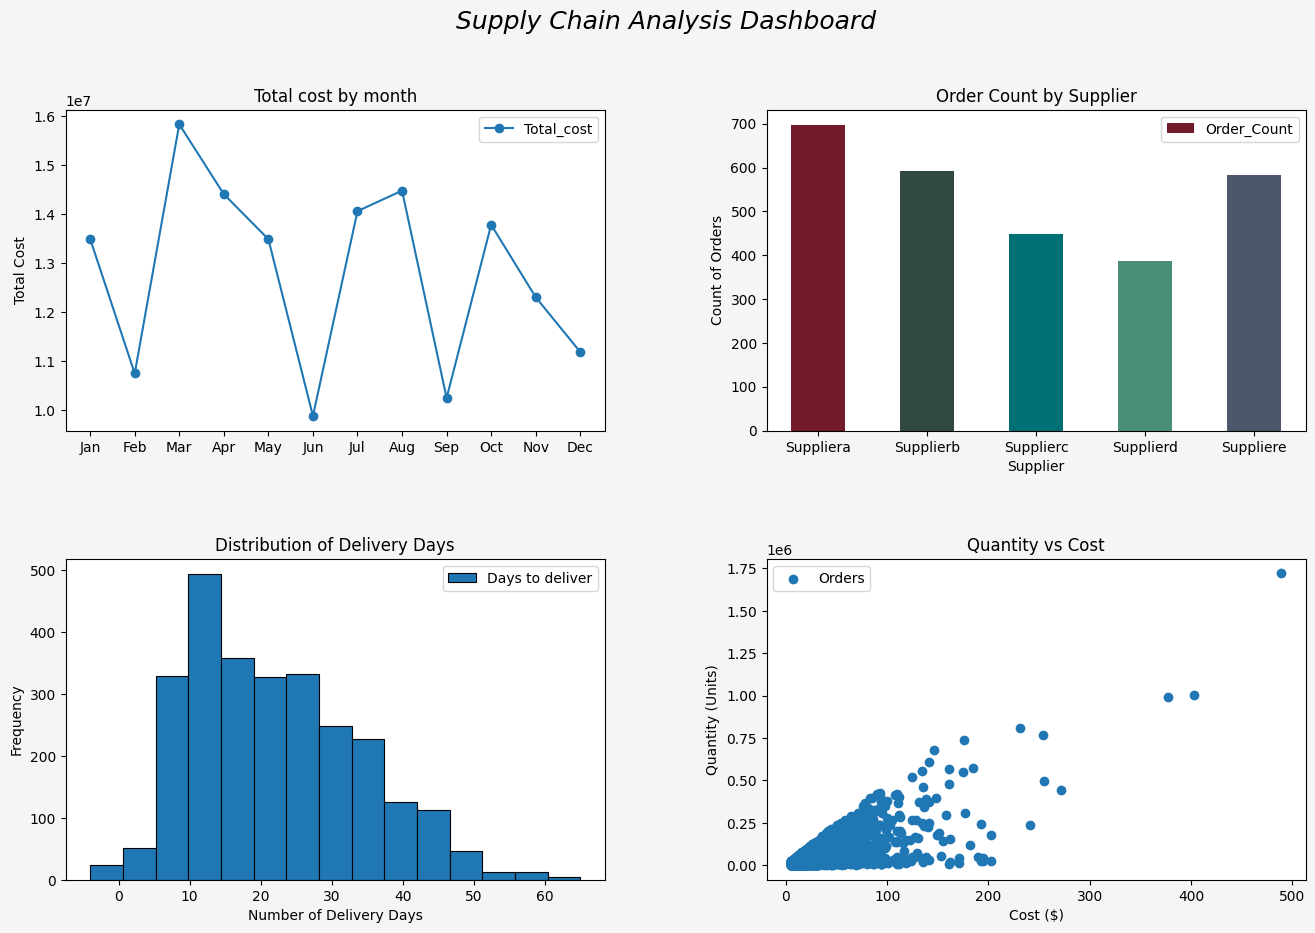

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#f5f5f5') #Figure background color 
plt.subplots_adjust(hspace=0.4, wspace=0.3) # Adjusts vertical space between rows and horizontal space between columns

# Subplot1
axes[0,0].plot(monthly_cost['order_month'], monthly_cost['total_cost'], marker= 'o', label='Total_cost')
axes[0,0].set_title('Total cost by month')
# axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Total Cost')
axes[0,0].legend()
# axes[0,0].tick_params(axis='x',rotation=45)

# Subplot 2
axes[0,1].bar(chart2['supplier_name'], chart2['order_count'], label='Order_Count', color=['#731b2b', '#324842', '#007075', '#4b8e79', '#4c5869'], width=0.5)
axes[0,1].set_title('Order Count by Supplier')
axes[0,1].set_xlabel('Supplier')
axes[0,1].set_ylabel('Count of Orders')
axes[0,1].legend()

# Subplot 3
axes[1,0].hist(df['days_to_deliver'], bins=15, label='Days to deliver', edgecolor='black', linewidth= 0.8)
axes[1,0].set_title('Distribution of Delivery Days')
axes[1,0].set_xlabel('Number of Delivery Days')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# Subplot 4
axes[1,1].scatter(df['quantity'], df['total_cost'], label='Orders')
axes[1,1].set_title('Quantity vs Cost')
axes[1,1].set_xlabel('Cost ($)')
axes[1,1].set_ylabel('Quantity (Units)')
axes[1,1].legend()

fig.suptitle('Supply Chain Analysis Dashboard', size='18', fontstyle='oblique') # Title of dashboard
fig.savefig('dashboard.png')
fig.show()


Extra Challenges 
Challenge 1: 
Create a bar chart showing on_time_rate for each supplier. 
Color the bars: green for suppliers with >90% on-time rate, yellow for 80-90%, red for <80%. This makes good and bad performers obvious at a glance. 

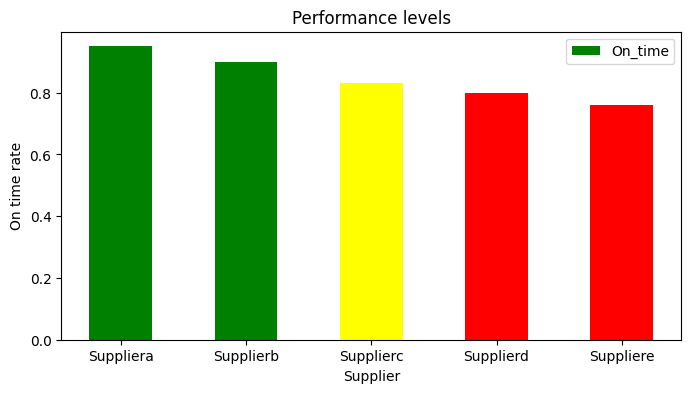

In [54]:
chart3 = df.groupby('supplier_name')['supplier_on_time_num_rate'].mean().reset_index()
color_bar = []
for rate in chart3['supplier_on_time_num_rate']:
    if rate > 0.90:
        color_bar.append('green')
    elif rate > 0.80 and rate <= 0.90:
        color_bar.append('yellow')
    else:
        color_bar.append('red')


plt.figure(figsize=(8,4))
plt.bar(chart3['supplier_name'], chart3['supplier_on_time_num_rate'], label='On_time', width=0.5, color=color_bar)
plt.title('Performance levels')
plt.legend()
plt.xlabel('Supplier')
plt.ylabel('On time rate')
plt.show()

Challenge 2: 
Create a line plot showing average order cost for each product_category over time (by month). 
Use different colors for different categories. 
Which products' costs are stable? Which are volatile? 

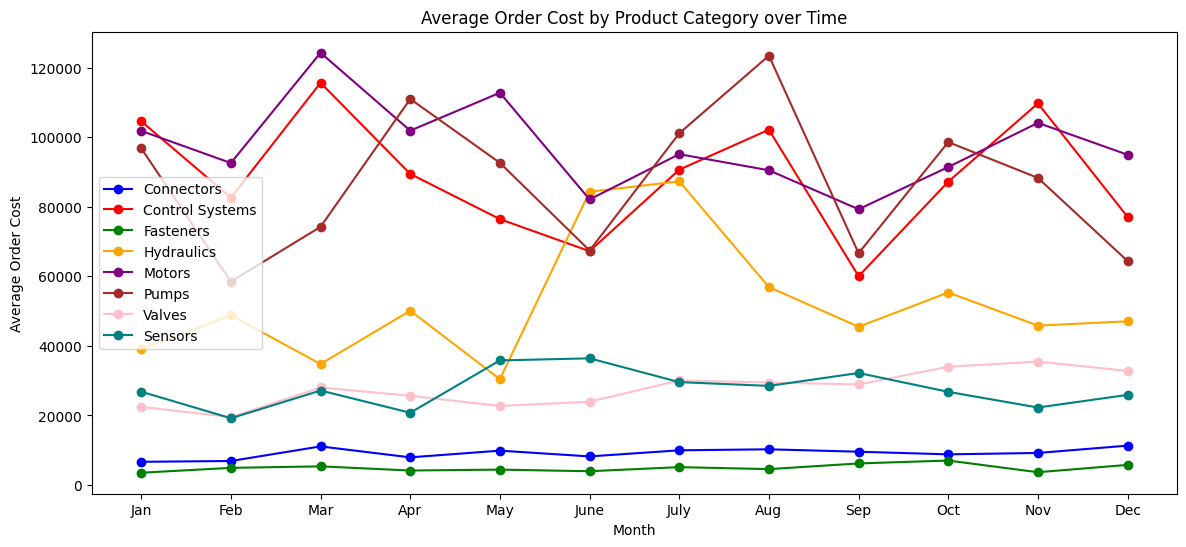

In [ ]:
# Group by product category and order month
chart4 = df.groupby(['product_category', 'order_month'])['total_cost'].mean().reset_index()
chart4 = chart4.sort_values('order_month')

month_names2 = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'June', 7: 'July', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
chart4['order_month'] = chart4['order_month'].map(month_names2)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Extract unique categories
categories = chart4['product_category'].unique()

# Colors for each category
category_colors = ['blue','red', 'green', 'orange', 'purple', 'brown', 'pink', 'teal']

# Plotting theline for the product category
plt.figure(figsize=(14, 6))
for i, category in enumerate(categories):
    category_data = chart4[chart4['product_category']== category]
    plt.plot(category_data['order_month'], category_data['total_cost'], marker= 'o', label=category, color=category_colors[i])

plt.title('Average Order Cost by Product Category over Time')
plt.xlabel('Month')
plt.ylabel('Average Order Cost')
plt.legend()
plt.show()

Volatile products that show instability are Pumps, Control systems, Motors and Hydraulics
Stable products with more stability are Fasteners, Connectors and Sensors

 
Challenge 3: 
Create a scatter plot showing the relationship between lead_time_days and days_to_deliver, colored by supplier_name. 
Do suppliers with long lead times consistently deliver on time? Do they over-promise or under-promise? 

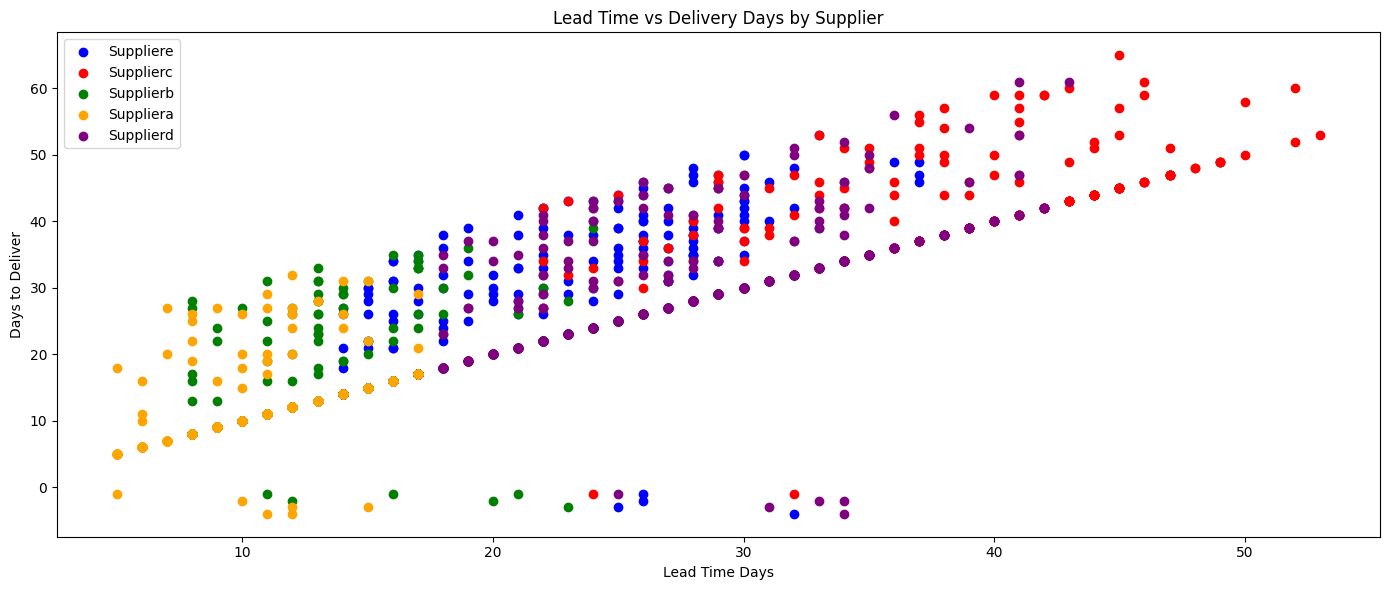

In [85]:
# Get unique suppliers
suppliers = df['supplier_name'].unique()
supplier_colors = ['blue', 'red', 'green', 'orange', 'purple']

plt.figure(figsize=(14, 6))
# Plot each supplier with a different color
for i, supplier in enumerate(suppliers):
    supplier_data = df[df['supplier_name']== supplier]
    plt.scatter(supplier_data['lead_time_days'],supplier_data['days_to_deliver'], label=supplier, color=supplier_colors[i])

plt.title('Lead Time vs Delivery Days by Supplier')
plt.xlabel('Lead Time Days')
plt.ylabel('Days to Deliver')
plt.legend()
plt.tight_layout()
plt.show()